In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pandas import read_csv


df=read_csv("catalog_products.xlsx - Sheet1 (1).csv")

numeric_cols=df.select_dtypes(include=[np.number]).columns
df[numeric_cols]=df[numeric_cols].astype(float)
df[numeric_cols]=df[numeric_cols].fillna(df[numeric_cols].mean())
print(df)

         col_1  col_2  col_3        col_4  col_5  col_6        col_7  col_8  \
0         Home  762.0  303.0  Electronics   49.0  348.0     Clothing  206.0   
1       Sports  190.0   34.0       Sports  107.0   99.0     Clothing  836.0   
2        Books  711.0    2.0         Home   93.0  876.0         Home  868.0   
3       Sports  484.0  362.0        Books  636.0  361.0         Home  897.0   
4       Sports  733.0  195.0         Home  829.0  937.0     Clothing  428.0   
...        ...    ...    ...          ...    ...    ...          ...    ...   
9995  Clothing  444.0  107.0         Home  429.0    1.0        Books   71.0   
9996     Books  434.0  857.0  Electronics  831.0  437.0       Sports  764.0   
9997  Clothing  228.0  937.0        Books  648.0  686.0  Electronics  847.0   
9998      Home  509.0  291.0       Sports  666.0  250.0     Clothing  231.0   
9999     Books  799.0  349.0        Books  294.0  410.0        Books  524.0   

      col_9       col_10  ...  col_41  col_42      

In [24]:
df["total_value"]=df["col_2"]*df["col_3"]
df["log_price"]=np.log(df["col_2"])
df["double_stock"]=df["col_3"]*2

In [25]:
mean_price=df["col_2"].mean()          #1.5
std_price=df["col_2"].std()
anomalies=df[(df["col_2"]>mean_price+3*std_price) | (df["col_2"]<mean_price-3*std_price)].copy()
print(anomalies)
df_clean=df.drop(anomalies.index)

Empty DataFrame
Columns: [col_1, col_2, col_3, col_4, col_5, col_6, col_7, col_8, col_9, col_10, col_11, col_12, col_13, col_14, col_15, col_16, col_17, col_18, col_19, col_20, col_21, col_22, col_23, col_24, col_25, col_26, col_27, col_28, col_29, col_30, col_31, col_32, col_33, col_34, col_35, col_36, col_37, col_38, col_39, col_40, col_41, col_42, col_43, col_44, col_45, col_46, col_47, col_48, col_49, col_50, total_value, log_price, double_stock]
Index: []

[0 rows x 53 columns]


In [26]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error

le=LabelEncoder()
df["col_7"]=le.fit_transform(df["col_7"])

X=df[["col_3"]]
y=df['col_2']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)

print(f"MAE:{mae:.2f}")
print(f"MSE:{mse:.2f}")

MAE:248.54
MSE:82536.70


In [27]:
X=df[["col_3","total_value", "double_stock", "log_price"]]
y=df["col_2"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)

print(f"MAE:{mae:.2f}")
print(f"MSE:{mse:.2f}")

MAE:78.85
MSE:11125.09


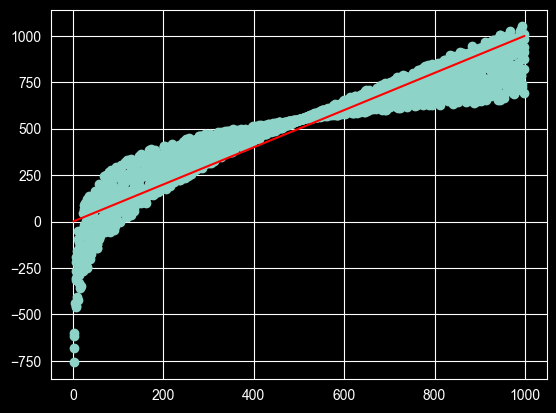

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         color="red")
plt.show()

In [29]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
cols=["col_3","total_value","double_stock","log_price"]
df[cols]=scaler.fit_transform(df[cols])
print(df[cols].mean())
print(df[cols].std())

col_3          -1.456613e-17
total_value    -1.563194e-17
double_stock   -1.456613e-17
log_price       2.236433e-16
dtype: float64
col_3           1.00005
total_value     1.00005
double_stock    1.00005
log_price       1.00005
dtype: float64


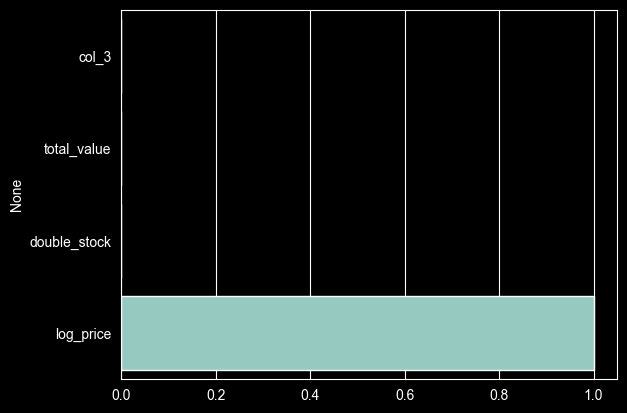

In [30]:
from sklearn.tree import DecisionTreeRegressor
X=df[["col_3","total_value", "double_stock", "log_price"]]
y=df["col_2"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=DecisionTreeRegressor()
model.fit(X_train,y_train)

importance=pd.Series(
    model.feature_importances_,
    index=X.columns
)
sns.barplot(x=importance.values,y=importance.index)
plt.show()